In [19]:
import pickle
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score


with open("processed_battery_features_v2.pkl", "rb") as f:
    feature_df = pickle.load(f)

feature_df = feature_df.dropna().copy()

In [20]:
# Grid Search Funktion für Random Forest Regressor

def run_rf_gridsearch(
    df,
    feature_columns,
    target_column="SOH"
):

    data = df[feature_columns + [target_column]].dropna()

    X = data[feature_columns]
    y = data[target_column]

    # Train/Test Split
    split_idx = int(len(data) * 0.8)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    # Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    param_grid = {
        "n_estimators": [100, 200, 500],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.8]
    }

    grid = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    pred = best_model.predict(X_test)

    return {
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "best_params": grid.best_params_,
        "best_model": best_model
    }

In [21]:
feature_groups = {

    # Nur DTW
    "dtw_only": [
        "DTW_V"
    ],

    # Einfache Kurvenabstände
    "curve_distance": [
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V"
    ],

    # Voltage-Features ohne DTW
    "voltage_simple": [
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "SlopeRMSE_V"
    ],

    # Bisheriges Voltage-Core Set
    "voltage_core": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean"
    ],

    # Nur Zeitinformationen
    "time_only": [
        "charge_duration",
        # "discharge_duration"
    ],

    # Nur Strominformationen
    "current_only": [
        "I_mean",
        "I_std",
        "DTW_I"
    ],

    # Voltage ohne Zeit
    "voltage_all": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V"
    ],

    # Voltage + Zeit
    "voltage+time": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V",
        "charge_duration",
        # "discharge_duration"
    ],

    # Alles
    "full": [
        "DTW_V",
        "DTW_I",

        "V_curvature",
        "V_std",
        "V_mean",
        "V_range",
        "V_slope_mean",
        "V_n_peaks",

        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V",

        "I_mean",
        "I_std",

        "charge_duration",
        # "discharge_duration"
    ]
}

In [22]:
results = []
best_models = {}

for name, features in feature_groups.items():

    print(f"Running {name} ...")

    result = run_rf_gridsearch(
        feature_df,
        features
    )

    best_models[name] = result["best_model"]

    results.append({
        "model": name,
        "MAE": result["MAE"],
        "R2": result["R2"],
        "best_params": str(result["best_params"])
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

print(results_df)

Running dtw_only ...
Running curve_distance ...
Running voltage_simple ...
Running voltage_core ...
Running time_only ...
Running current_only ...
Running voltage_all ...
Running voltage+time ...
Running full ...
            model       MAE        R2  \
8            full  0.007705  0.971620   
7    voltage+time  0.007829  0.971059   
6     voltage_all  0.009187  0.940368   
5    current_only  0.010065  0.930821   
2  voltage_simple  0.010441  0.922390   
1  curve_distance  0.013265  0.921227   
3    voltage_core  0.010866  0.910717   
0        dtw_only  0.027085  0.689452   
4       time_only  0.044182  0.380161   

                                         best_params  
8  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
7  {'max_depth': None, 'max_features': 0.8, 'min_...  
6  {'max_depth': None, 'max_features': 0.8, 'min_...  
5  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
2  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
1  {'max_depth': None, 'max_features': 0.8, 'm

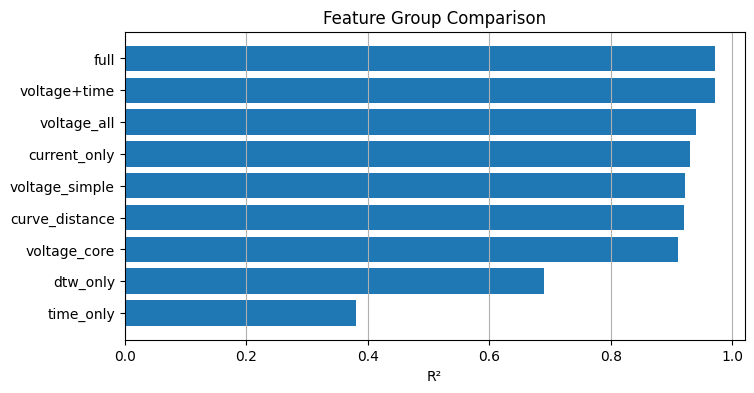

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.barh(
    results_df["model"],
    results_df["R2"]
)

plt.xlabel("R²")
plt.title("Feature Group Comparison")

plt.grid(axis="x")

plt.gca().invert_yaxis()

plt.show()

In [24]:
voltage_features = [
    "DTW_V",
    "RMSE_V",
    "AreaDiff_V",
    "Corr_V",
    "MaxDev_V",
    "SlopeRMSE_V",
    "V_curvature",
    "V_std",
    "V_mean"
]

feature_df[voltage_features].corr()

,DTW_V,RMSE_V,AreaDiff_V,Corr_V,MaxDev_V,SlopeRMSE_V,V_curvature,V_std,V_mean
DTW_V,1.000000,0.771003,0.746475,-0.756556,0.883735,0.033241,0.212291,-0.324153,0.643854
RMSE_V,0.771003,1.000000,0.992180,-0.928814,0.860930,0.140429,0.097527,0.119404,0.304458
AreaDiff_V,0.746475,0.992180,1.000000,-0.885289,0.810397,0.110181,0.084269,0.159435,0.267575
Corr_V,-0.756556,-0.928814,-0.885289,1.000000,-0.905552,-0.178673,-0.154248,-0.012351,-0.334659
MaxDev_V,0.883735,0.860930,0.810397,-0.905552,1.000000,0.262123,0.167994,-0.219392,0.560305
SlopeRMSE_V,0.033241,0.140429,0.110181,-0.178673,0.262123,1.000000,0.218150,0.254090,0.036567
V_curvature,0.212291,0.097527,0.084269,-0.154248,0.167994,0.218150,1.000000,-0.013832,0.021946
V_std,-0.324153,0.119404,0.159435,-0.012351,-0.219392,0.254090,-0.013832,1.000000,-0.511330
V_mean,0.643854,0.304458,0.267575,-0.334659,0.560305,0.036567,0.021946,-0.511330,1.000000


In [25]:
from sklearn.inspection import permutation_importance

def permutation_report(model_name):

    features_used = feature_groups[model_name]

    data = feature_df[features_used + ["SOH"]].dropna()

    X = data[features_used]
    y = data["SOH"]

    split_idx = int(len(data) * 0.8)

    X_test = X.iloc[split_idx:]
    y_test = y.iloc[split_idx:]

    result = permutation_importance(
        best_models[model_name],
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": result.importances_mean,
        "std": result.importances_std
    }).sort_values(
        "importance",
        ascending=False
    )

    return importance_df

In [26]:
permutation_report("time_only")

,feature,importance,std
0,charge_duration,1.018954,0.039115


In [27]:
permutation_report("voltage+time")

,feature,importance,std
0,DTW_V,0.845655,0.030947
9,charge_duration,0.130881,0.008459
3,V_mean,0.111563,0.005347
1,V_curvature,0.093515,0.007527
5,AreaDiff_V,0.063293,0.003858
4,RMSE_V,0.029495,0.002630
6,Corr_V,0.023331,0.001274
2,V_std,0.014493,0.001500
7,MaxDev_V,0.004501,0.000904
8,SlopeRMSE_V,0.001115,0.000459


In [28]:
permutation_report("full")

,feature,importance,std
0,DTW_V,0.607420,0.026818
14,I_std,0.132073,0.012390
15,charge_duration,0.089070,0.005932
10,Corr_V,0.078946,0.002976
9,AreaDiff_V,0.028515,0.002145
13,I_mean,0.026984,0.001597
1,DTW_I,0.025475,0.002384
4,V_mean,0.018295,0.001120
2,V_curvature,0.006750,0.000820
8,RMSE_V,0.006550,0.000759


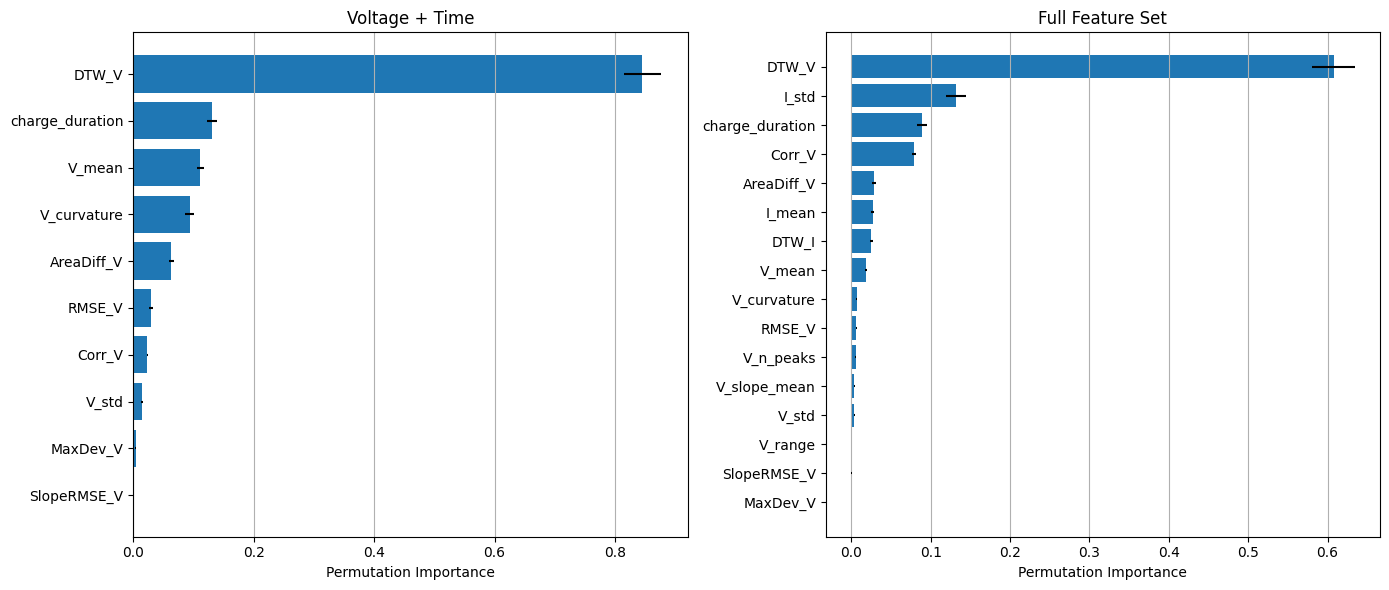

: 

In [ ]:
perm_vt = permutation_report("voltage+time")
perm_full = permutation_report("full")

perm_vt = perm_vt.sort_values("importance", ascending=True)
perm_full = perm_full.sort_values("importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(
    perm_vt["feature"],
    perm_vt["importance"],
    xerr=perm_vt["std"]
)
axes[0].set_title("Voltage + Time")
axes[0].set_xlabel("Permutation Importance")
axes[0].grid(axis="x")

axes[1].barh(
    perm_full["feature"],
    perm_full["importance"],
    xerr=perm_full["std"]
)
axes[1].set_title("Full Feature Set")
axes[1].set_xlabel("Permutation Importance")
axes[1].grid(axis="x")

plt.tight_layout()
plt.show()